In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime
import pandas as pd
import plotly.express as px

mpl.rcParams['figure.figsize'] = (10, 8)
mpl.rcParams['axes.grid'] = False


In [5]:
df = pd.read_csv('https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/nyc_taxi.csv')

In [6]:
df.sample(5)

,timestamp,value
1290,2014-07-27 21:00:00,18252
4966,2014-10-12 11:00:00,18438
9180,2015-01-08 06:00:00,6627
7894,2014-12-12 11:00:00,18237
4249,2014-09-27 12:30:00,19968


In [7]:
df['timestamp']=pd.to_datetime(df['timestamp'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10320 entries, 0 to 10319
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  10320 non-null  datetime64[ns]
 1   value      10320 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 161.4 KB


In [9]:
df.head()

,timestamp,value
0,2014-07-01 00:00:00,10844
1,2014-07-01 00:30:00,8127
2,2014-07-01 01:00:00,6210
3,2014-07-01 01:30:00,4656
4,2014-07-01 02:00:00,3820


In [10]:
df=df.set_index('timestamp').resample("H").mean()

/tmp/ipykernel_56339/2135893105.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df=df.set_index('timestamp').resample("H").mean()


In [11]:
df

,value
timestamp,
2014-07-01 00:00:00,9485.5
2014-07-01 01:00:00,5433.0
2014-07-01 02:00:00,3346.5
2014-07-01 03:00:00,2216.5
2014-07-01 04:00:00,2189.5
...,...
2015-01-31 19:00:00,28288.5
2015-01-31 20:00:00,24138.0
2015-01-31 21:00:00,24194.5


In [12]:
fig = px.line(df.reset_index(), x='timestamp', y='value', title='NYC Taxi Demand')

fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(count=2, label="3y", step="year", stepmode="backward"),
            dict(count=3, label="5y", step="year", stepmode="backward"),
            dict(step="all")
        ])
    )
)
fig.show()

In [13]:
from prophet import Prophet

In [14]:
taxi_df=df.reset_index()[['timestamp','value']].rename({'timestamp':'ds','value':'y'}, axis='columns')

In [15]:
taxi_df

,ds,y
0,2014-07-01 00:00:00,9485.5
1,2014-07-01 01:00:00,5433.0
2,2014-07-01 02:00:00,3346.5
3,2014-07-01 03:00:00,2216.5
4,2014-07-01 04:00:00,2189.5
...,...,...
5155,2015-01-31 19:00:00,28288.5
5156,2015-01-31 20:00:00,24138.0
5157,2015-01-31 21:00:00,24194.5
5158,2015-01-31 22:00:00,26515.0


In [16]:
train=taxi_df[(taxi_df['ds'] >= '2014-07-01') & (taxi_df['ds'] <= '2015-01-27')]
test=taxi_df[(taxi_df['ds'] > '2015-01-27')]

In [17]:
train.shape

(5041, 2)

In [18]:
test.shape

(119, 2)

In [19]:
test

,ds,y
5041,2015-01-27 01:00:00,39.5
5042,2015-01-27 02:00:00,29.0
5043,2015-01-27 03:00:00,9.5
5044,2015-01-27 04:00:00,14.5
5045,2015-01-27 05:00:00,29.0
...,...,...
5155,2015-01-31 19:00:00,28288.5
5156,2015-01-31 20:00:00,24138.0
5157,2015-01-31 21:00:00,24194.5
5158,2015-01-31 22:00:00,26515.0


In [20]:
m = Prophet(changepoint_range=0.95)

In [21]:
m.fit(train)

23:54:15 - cmdstanpy - INFO - Chain [1] start processing
23:54:15 - cmdstanpy - INFO - Chain [1] done processing


In [22]:
future = m.make_future_dataframe(periods=119,freq='H')
future.tail(167)

/home/nirdesho6o/miniconda3/envs/jupyter_env/lib/python3.14/site-packages/prophet/forecaster.py:1875: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



,ds
4993,2015-01-25 01:00:00
4994,2015-01-25 02:00:00
4995,2015-01-25 03:00:00
4996,2015-01-25 04:00:00
4997,2015-01-25 05:00:00
...,...
5155,2015-01-31 19:00:00
5156,2015-01-31 20:00:00
5157,2015-01-31 21:00:00
5158,2015-01-31 22:00:00


In [23]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
5155,2015-01-31 19:00:00,23778.600174,19035.397767,28860.107236
5156,2015-01-31 20:00:00,24342.620526,19637.463685,29153.033728
5157,2015-01-31 21:00:00,23219.306963,18369.460198,28070.011160
5158,2015-01-31 22:00:00,21027.352014,16058.414530,26077.619653
5159,2015-01-31 23:00:00,18500.214782,13625.464477,23730.212758


In [24]:
results=pd.concat([taxi_df.set_index('ds')['y'],forecast.set_index('ds')[['yhat', 'yhat_lower', 'yhat_upper']]],axis=1)

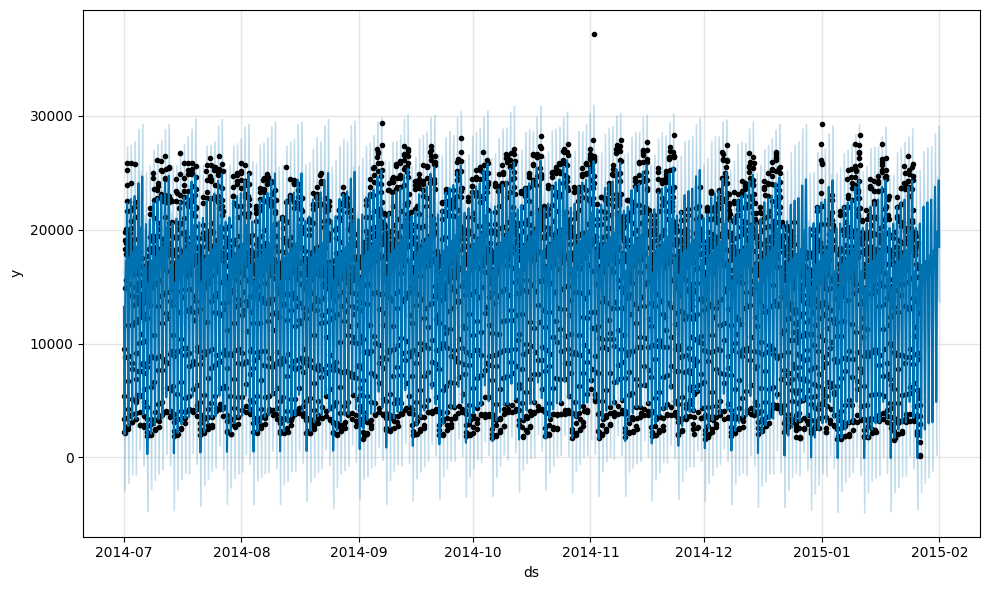

In [25]:
fig1 = m.plot(forecast)

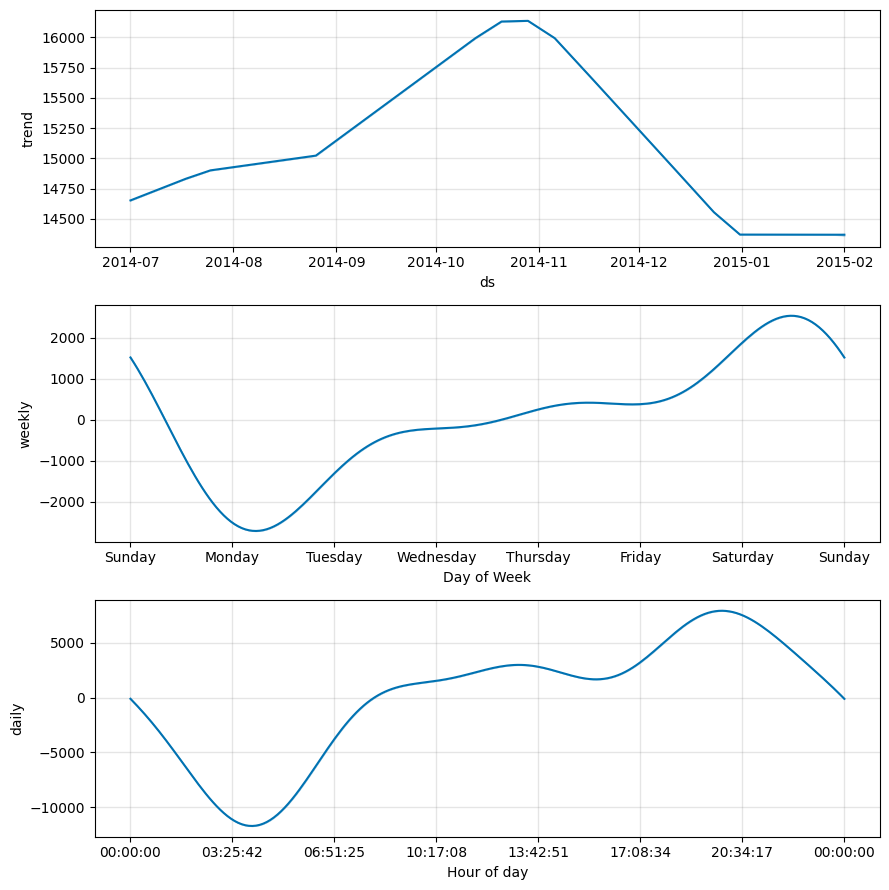

In [26]:
comp=m.plot_components(forecast)

In [27]:
results

,y,yhat,yhat_lower,yhat_upper
ds,,,,
2014-07-01 00:00:00,9485.5,13225.646458,8816.126752,18002.225679
2014-07-01 01:00:00,5433.0,10217.393309,5686.736259,15295.739477
2014-07-01 02:00:00,3346.5,6653.987422,1809.282978,11275.047543
2014-07-01 03:00:00,2216.5,3432.910433,-1294.841026,8484.659178
2014-07-01 04:00:00,2189.5,2002.226505,-2902.208097,6625.357154
...,...,...,...,...
2015-01-31 19:00:00,28288.5,23778.600174,19035.397767,28860.107236
2015-01-31 20:00:00,24138.0,24342.620526,19637.463685,29153.033728
2015-01-31 21:00:00,24194.5,23219.306963,18369.460198,28070.011160


In [28]:
results['error'] = results['y'] - results['yhat']

In [29]:
results["uncertainty"] = results['yhat_upper'] - results['yhat_lower']

In [30]:
results

,y,yhat,yhat_lower,yhat_upper,error,uncertainty
ds,,,,,,
2014-07-01 00:00:00,9485.5,13225.646458,8816.126752,18002.225679,-3740.146458,9186.098927
2014-07-01 01:00:00,5433.0,10217.393309,5686.736259,15295.739477,-4784.393309,9609.003218
2014-07-01 02:00:00,3346.5,6653.987422,1809.282978,11275.047543,-3307.487422,9465.764564
2014-07-01 03:00:00,2216.5,3432.910433,-1294.841026,8484.659178,-1216.410433,9779.500204
2014-07-01 04:00:00,2189.5,2002.226505,-2902.208097,6625.357154,187.273495,9527.565251
...,...,...,...,...,...,...
2015-01-31 19:00:00,28288.5,23778.600174,19035.397767,28860.107236,4509.899826,9824.709469
2015-01-31 20:00:00,24138.0,24342.620526,19637.463685,29153.033728,-204.620526,9515.570043
2015-01-31 21:00:00,24194.5,23219.306963,18369.460198,28070.011160,975.193037,9700.550962


In [31]:
results[results['error'].abs() >  1.5*results['uncertainty']]

,y,yhat,yhat_lower,yhat_upper,error,uncertainty
ds,,,,,,
2014-11-02 01:00:00,37204.5,14193.929526,9389.935548,18793.384026,23010.570474,9403.448478
2015-01-01 01:00:00,29292.0,11421.207501,6691.378919,16146.895170,17870.792499,9455.516250
2015-01-01 02:00:00,25753.5,7785.709474,3140.892938,12676.350276,17967.790526,9535.457338
2015-01-01 03:00:00,22067.0,4494.531115,-611.924389,9257.699923,17572.468885,9869.624312
2015-01-26 19:00:00,4565.5,19773.849664,15135.204595,24626.339694,-15208.349664,9491.135099
2015-01-26 20:00:00,3630.5,20549.111887,15880.934446,25276.183374,-16918.611887,9395.248928
2015-01-26 21:00:00,2907.0,19650.237618,14388.434027,24213.458422,-16743.237618,9825.024396
2015-01-26 22:00:00,1324.5,17694.509542,12726.209785,22597.504939,-16370.009542,9871.295154
2015-01-26 23:00:00,243.0,15413.916122,10851.044346,20447.978188,-15170.916122,9596.933842


In [32]:
results['anomaly'] = results.apply(lambda x: 'Yes' if(np.abs(x['error']) >  1.5*x['uncertainty']) else 'No', axis=1)

In [33]:
results

,y,yhat,yhat_lower,yhat_upper,error,uncertainty,anomaly
ds,,,,,,,
2014-07-01 00:00:00,9485.5,13225.646458,8816.126752,18002.225679,-3740.146458,9186.098927,No
2014-07-01 01:00:00,5433.0,10217.393309,5686.736259,15295.739477,-4784.393309,9609.003218,No
2014-07-01 02:00:00,3346.5,6653.987422,1809.282978,11275.047543,-3307.487422,9465.764564,No
2014-07-01 03:00:00,2216.5,3432.910433,-1294.841026,8484.659178,-1216.410433,9779.500204,No
2014-07-01 04:00:00,2189.5,2002.226505,-2902.208097,6625.357154,187.273495,9527.565251,No
...,...,...,...,...,...,...,...
2015-01-31 19:00:00,28288.5,23778.600174,19035.397767,28860.107236,4509.899826,9824.709469,No
2015-01-31 20:00:00,24138.0,24342.620526,19637.463685,29153.033728,-204.620526,9515.570043,No
2015-01-31 21:00:00,24194.5,23219.306963,18369.460198,28070.011160,975.193037,9700.550962,No


In [34]:
fig = px.scatter(results.reset_index(), x='ds', y='y', color='anomaly', title='NYC Taxi Demand')

fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(count=2, label="3y", step="year", stepmode="backward"),
            dict(count=3, label="5y", step="year", stepmode="backward"),
            dict(step="all")
        ])
    )
)
fig.show()

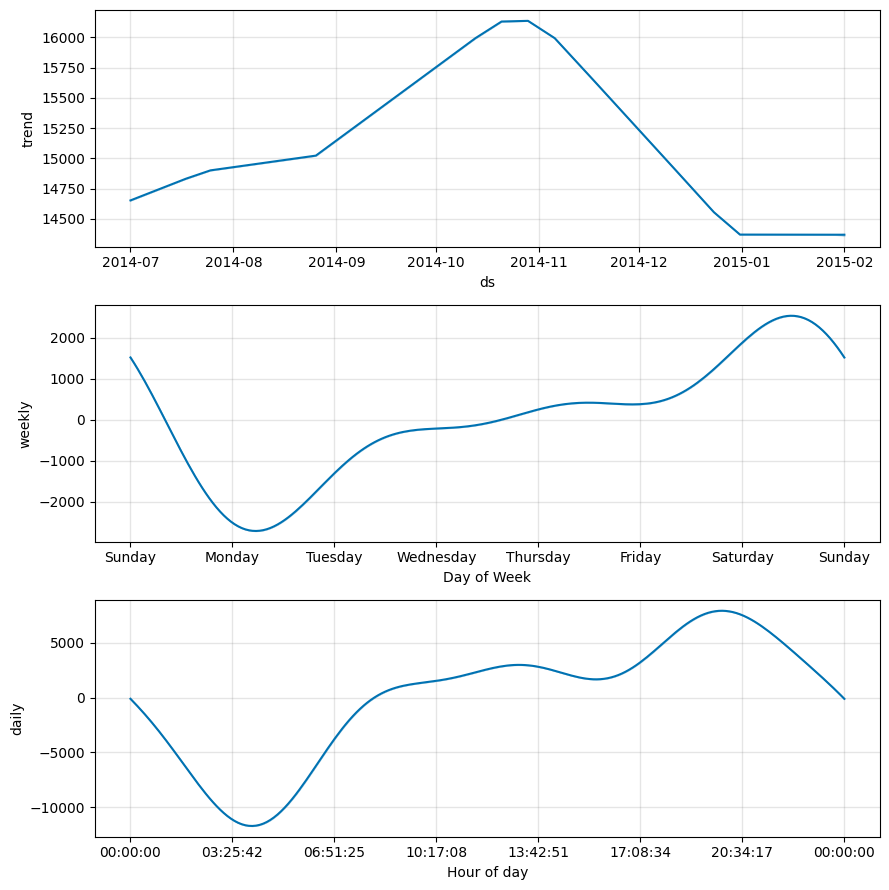

In [35]:
comp=m.plot_components(forecast)